# GRAFT

In [1]:
from os.path import join, isfile, isdir
from os import listdir
from multiprocessing import Pool
from PIL import Image
from torchvision import transforms
from tqdm import tqdm
import numpy as np
import torch.nn.functional as F
from shutil import copy
import torch.nn as nn
import requests
import matplotlib.pyplot as plt
import urllib.request
from transformers import CLIPVisionModelWithProjection, CLIPTextModelWithProjection, AutoTokenizer
import torch
import io

/home/gridsan/manderson/.conda/envs/ovdsat/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
class GRAFT(nn.Module):
    def __init__(self, CLIP_version="weights/clip-vit-base-patch16", temp=False, bias_projector=True):
        super().__init__()
        # satellite image backbone
        self.satellite_image_backbone = CLIPVisionModelWithProjection.from_pretrained(CLIP_version)
        self.patch_size = self.satellite_image_backbone.config.patch_size

        self.projector = nn.Sequential(
            nn.LayerNorm(self.satellite_image_backbone.config.hidden_size, eps=self.satellite_image_backbone.config.layer_norm_eps),
            nn.Linear(self.satellite_image_backbone.config.hidden_size, self.satellite_image_backbone.config.projection_dim, bias=bias_projector),
        )
        self.patch_size = self.satellite_image_backbone.config.patch_size
        self.norm_dim = -1

        self.temp = temp
        if temp:
            self.register_buffer("logit_scale", torch.ones([]) * (1 / 0.07))

    def forward(self, image_tensor):
        # Extract features from satellite images
        # B x 197 x 768 for VIT-B/16
        hidden_state = self.satellite_image_backbone(image_tensor).last_hidden_state
        # B x 197 x 512
        satellite_image_features = F.normalize(self.projector(hidden_state), dim=self.norm_dim)
        # get the satellite image features
        return satellite_image_features

    def forward_features(self, image_tensor):
        # Extract features from satellite images
        # B x 512 for VIT-B/16
        embed = self.satellite_image_backbone(image_tensor).image_embeds
        # B x 512
        satellite_image_features = F.normalize(embed)
        return satellite_image_features

In [6]:
ckpt_path = 'weights/graft.cs.cornell.edu/static/models/e96c9fbd1ee2ca1b3c253c94761e1ffb/graft_naip.ckpt'

In [8]:
device="cuda"
model = GRAFT(temp=True, bias_projector=False).to(device)
transform = transforms.Compose([transforms.Resize((224, 224)),
  transforms.ToTensor(),
  transforms.Normalize(mean=[0.48145466, 0.4578275, 0.40821073], std=[0.26862954, 0.26130258, 0.27577711])])
sd = torch.load(ckpt_path)
model.load_state_dict(sd['state_dict'], strict=False)
textmodel = CLIPTextModelWithProjection.from_pretrained("weights/clip-vit-base-patch16").eval().to(device)
tokenizer = AutoTokenizer.from_pretrained("weights/clip-vit-base-patch16")

In [9]:
model

GRAFT(
  (satellite_image_backbone): CLIPVisionModelWithProjection(
    (vision_model): CLIPVisionTransformer(
      (embeddings): CLIPVisionEmbeddings(
        (patch_embedding): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16), bias=False)
        (position_embedding): Embedding(197, 768)
      )
      (pre_layrnorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (encoder): CLIPEncoder(
        (layers): ModuleList(
          (0-11): 12 x CLIPEncoderLayer(
            (self_attn): CLIPAttention(
              (k_proj): Linear(in_features=768, out_features=768, bias=True)
              (v_proj): Linear(in_features=768, out_features=768, bias=True)
              (q_proj): Linear(in_features=768, out_features=768, bias=True)
              (out_proj): Linear(in_features=768, out_features=768, bias=True)
            )
            (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
            (mlp): CLIPMLP(
              (activation_fn): QuickGELUActiva

In [11]:
def zero_shot_classification(image, classes=None):
  with torch.no_grad():
    tr_image = transform(image).unsqueeze(0).to(device)
    image_feature = model.forward_features(tr_image)
  if classes is not None:
    texts = classes
  else:
    texts = ["tennis courts", "parking lot", "farmland", "lake", "park", "powerlines", "University Campus", "Beach", "Freeway"]
  with torch.no_grad():
    textsenc = tokenizer(texts, padding=True, return_tensors="pt").to(device) #tokenize
    class_embeddings = F.normalize(textmodel(**textsenc).text_embeds, dim=-1) #embed with text encoder
  classlogits = image_feature.cpu().numpy() @ class_embeddings.cpu().numpy().T
  fig = plt.figure(figsize=(10, 5))
  plt.subplot(1, 2, 1)
  plt.title("Input Image")
  plt.imshow(image)
  plt.axis('Off')
  plt.subplot(1, 2, 2)
  plt.ylabel('Class matching score')
  plt.xlabel('Classes')
  plt.title("Graft best prediction: '{}'".format(texts[np.argmax(classlogits[0])]))
  plt.bar(range(len(classlogits[0])), classlogits[0])
  plt.xticks(range(len(texts)), texts, rotation=90)
  plt.show()
  return classlogits

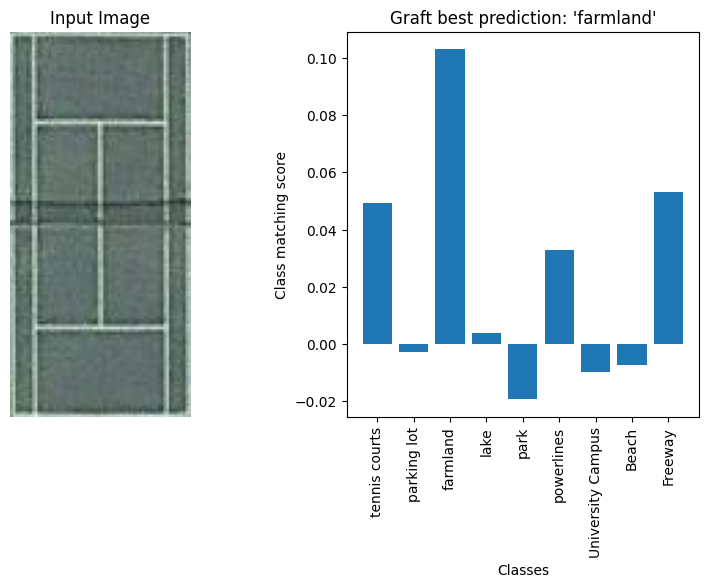

array([[ 0.04935116, -0.00274494,  0.10296077,  0.00402707, -0.01925984,
         0.0327321 , -0.0098104 , -0.00746294,  0.05319295]],
      dtype=float32)

In [12]:
image = Image.open("data/cropped_data/dior/train/dior_N1-1/tenniscourt/17086_17.jpg")
zero_shot_classification(image)

# CLIP-RSICD

In [13]:
from PIL import Image
import requests
from transformers import CLIPProcessor, CLIPModel

In [14]:
model = CLIPModel.from_pretrained("weights/clip-rsicd-v2")
processor = CLIPProcessor.from_pretrained("weights/clip-rsicd-v2")

In [15]:
image = Image.open("data/cropped_data/dior/train/dior_N1-1/airport/3420_16.jpg")

labels = ["residential area", "playground", "stadium", "forest", "airport"]
inputs = processor(text=[f"a photo of a {l}" for l in labels], images=image, return_tensors="pt", padding=True)

outputs = model(**inputs)
logits_per_image = outputs.logits_per_image # this is the image-text similarity score
probs = logits_per_image.softmax(dim=1) # we can take the softmax to get the label probabilities
for l, p in zip(labels, probs[0]):
    print(f"{l:<16} {p:.4f}")

residential area 0.0002
playground       0.0001
stadium          0.0000
forest           0.0000
airport          0.9996
